## Research Report #2 for SOCIOL728

Dataset chosen: CielNet data from the \`networkdata\` package.

## I. Get Your Network: Data Description

The CielNet data are part of a study of criminal social networks carried out by Carlo Morselli. The Ciel Data consists of a small drug-importation network that was importing liquid hashish from Jamaica to Montreal. It was intercepted by Canadian authorities in 1996-97. Although a total of 75 people were surveiled as part of the investigation, the anonymous social network dataset contains 25 active members in the drug transportation network.

#### Motivation for Studying this Dataset:

The CielNet dataset contains crucial information within the size constraint of being small enough for a preliminary analysis as required by this assignment. The ties represent communication between various people involved in drug transportation, which presents an appropriate opportunity for social networks analysis. The data have been cleaned and anonymized, presented as an \`igraph\` object in R, making analysis convenient. According to author and researcher Carlo Morselli, this analysis helped test some assumptions in the field of criminal networks analysis that had been unchallenged earlier: scholars often over-estimated or under-estimated the necessity of having a strong organizational structure for criminal activity. It was easy to argue that criminals maintained a rigid hierarchy and reporting structure. It was also easy to assume that adversarial conditions and chaotic situations made such hierarchies fragile. Social networks analysis can measure centrality and hierarchy in such networks, providing evidence for their organizational structure.

#### Social Networks Concepts Relevant to this Dataset:

The dataset presents undirected ties for communication frequency between various members (nodes). Weights can be assigned to ties based on the frequency of communication. Measures of centrality and hierarchy will be important to reveal "leader" and "lieutenant" nodes, which were primary targets during the investigation by Montreal authorities. It would also be helpful to identify clusters or communities within this network in order to trace details in the organizational structure and possible flow of goods as well as information.

#### Code to Load Data and Prepare a Preliminary Visualization:

In [2]:
#setwd("/Users/ananyajogalekar/Library/CloudStorage/GoogleDrive-ananyajogalekar5@gmail.com/My Drive/Duke University/00-Coursework/SOCIOL728-SNA")

library(igraph)

In [3]:
#| message: false
# | warning: false
install.packages("drat")
drat::addRepo("schochastics")
install.packages("networkdata")


The downloaded binary packages are in
	/var/folders/yw/zr51wswj5pl5h03k4z3_qznr0000gn/T//RtmpM8Nr6T/downloaded_packages


Warning message:
“unable to access index for repository https://schochastics.github.io/drat/bin/macosx/big-sur-arm64/contrib/4.5:
  cannot open URL 'https://schochastics.github.io/drat/bin/macosx/big-sur-arm64/contrib/4.5/PACKAGES'”
installing the source package ‘networkdata’




Selecting the network of interest using its package: covert_12 for the CielNet data

In [4]:
ciel_data = networkdata::covert_12

This graph was created by an old(er) igraph version.
ℹ Call `igraph::upgrade_graph()` on it to use with the current igraph version.
For now we convert it on the fly...


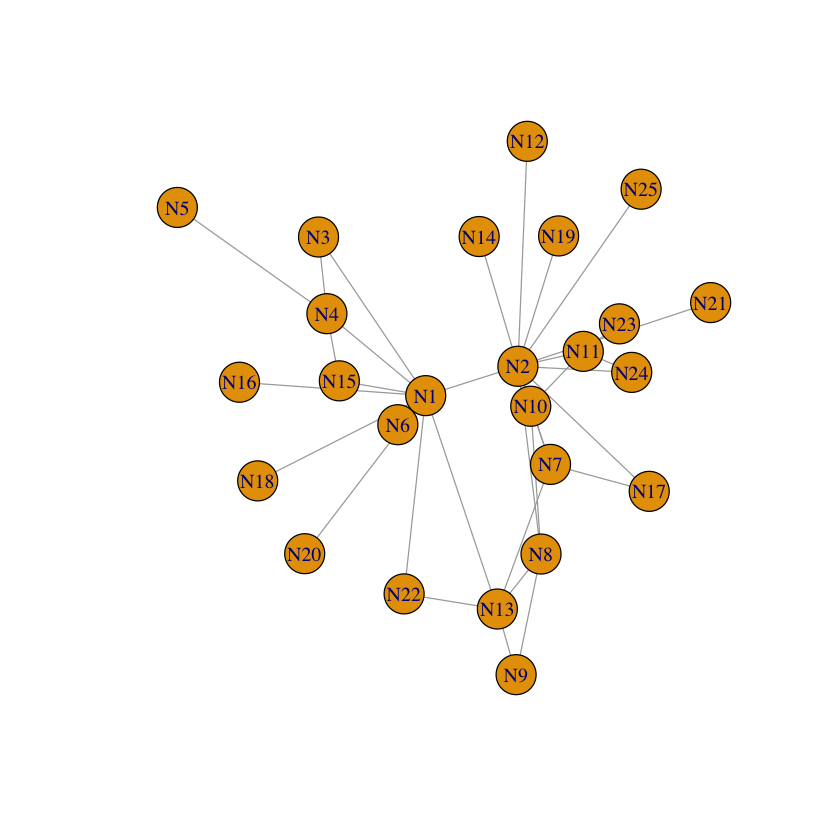

In [5]:
plot(ciel_data)

# II. Visualize the Network

Below is code for getting some useful measures and making better visualizations.

### Dyad and Triad Census

In [6]:
data("covert_12")

# Calculate Dyad Census
# For undirected graphs, this identifies "mut" (edges) and "null" (no edges)
dyad_results <- dyad_census(ciel_data)
print("Dyad Census:")
print(dyad_results)

# Calculate Triad Census
triad_results <- triad_census(ciel_data)
print("Triad Census:")
print(triad_results)

Warning message in data("covert_12"):
“data set ‘covert_12’ not found”
Warning message:
“`dyad_census()` requires a directed graph.”


[1] "Dyad Census:"
$mut
[1] 35

$asym
[1] 0

$null
[1] 265



Warning message in triad_census(ciel_data):
“At vendor/cigraph/src/misc/motifs.c:1157 : Triad census called on an undirected graph. All connections will be treated as mutual.”


[1] "Triad Census:"
 [1] 1643    0  518    0    0    0    0    0    0    0  130    0    0    0    0
[16]    9


### Inspecting the network

In [7]:
igraph::degree(ciel_data)
igraph::is.directed(ciel_data)
igraph::is.weighted(ciel_data)

N1  N2  N3  N4  N5  N6  N7  N8  N9 N10 N11 N12 N13 N14 N15 N16 N17 N18 N19 N20 
 10  12   2   4   1   1   4   4   2   4   4   1   5   1   2   1   2   1   1   1 
N21 N22 N23 N24 N25 
  1   2   1   2   1

Warning message:
“`is.directed()` was deprecated in igraph 2.0.0.
ℹ Please use `is_directed()` instead.”


[1] FALSE

Warning message:
“`is.weighted()` was deprecated in igraph 2.0.0.
ℹ Please use `is_weighted()` instead.”


[1] TRUE

We see that the network is undirected and weighted. So we should inspect the weights.

In [8]:
igraph::E(ciel_data)$weight
summary(igraph::E(ciel_data)$weight)

[1] 21  1  4 17  1  3  1  1  1  1  5  1 22 15  1  2  1  2  1  1  1  1  1  1  1
[26]  1  1  1  1  2  9  1 20 10  1

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    1.0     1.0     1.0     4.4     3.5    22.0 

These weights seem to represent the strength of ties, i.e. frequency of communication among members of the network.

### Measures of Centrality and Hierarchy

We create distance weights (for shortest paths):

In [9]:
dist_weights <- 1 / igraph::E(ciel_data)$weight

Centrality Measures:

In [10]:
strength_vals <- igraph::strength(ciel_data)

bet_vals <- igraph::betweenness(
  ciel_data,
  weights = dist_weights,
  normalized = TRUE
)

clo_vals <- igraph::closeness(
  ciel_data,
  weights = dist_weights,
  normalized = TRUE
)

eig_vals <- igraph::eigen_centrality(
  ciel_data,
  weights = igraph::E(ciel_data)$weight
)$vector

In [11]:
centrality_table <- data.frame(
  strength = strength_vals,
  betweenness = bet_vals,
  closeness = clo_vals,
  eigenvector = eig_vals
)

centrality_table

,strength,betweenness,closeness,eigenvector
,<dbl>,<dbl>,<dbl>,<dbl>
N1,51,0.670289855,1.4798582,0.699161010
N2,73,0.717391304,1.4842162,1.000000000
N3,2,0.000000000,0.6198704,0.020154880
N4,7,0.083333333,1.1311273,0.074869892
N5,1,0.000000000,0.5427682,0.001949526
N6,17,0.000000000,1.3659094,0.309491017
N7,8,0.007246377,1.1955220,0.147130748
N8,5,0.000000000,0.6764024,0.043078148
N9,10,0.000000000,0.6498699,0.007329527


### Hierarchy Measures:

Degree Centralization:

In [12]:
strength_vals <- igraph::strength(ciel_data)

In [13]:
max_strength <- max(strength_vals)
n <- igraph::vcount(ciel_data)

centralization_strength <-
  sum(max_strength - strength_vals) /
  ((n - 1) * (n - 2))   # normalization for undirected network

centralization_strength

[1] 2.748188

Weighted Betweenness Centralization:

In [14]:
dist_weights <- 1 / igraph::E(ciel_data)$weight

bet_vals <- igraph::betweenness(
  ciel_data,
  weights = dist_weights,
  normalized = FALSE
)

max_bet <- max(bet_vals)

centralization_bet <-
  sum(max_bet - bet_vals) /
  ((n - 1) * (n - 2) * (n - 3) / 2)

centralization_bet

[1] 0.7366601

Weighted Closeness Centralization:

In [15]:
clo_vals <- igraph::closeness(
  ciel_data,
  weights = dist_weights,
  normalized = FALSE
)

max_clo <- max(clo_vals)

centralization_clo <-
  sum(max_clo - clo_vals) /
  ((n - 1) * (n - 2) / (2*n - 3))

centralization_clo

[1] 0.05071381

# Visualizations

Show Tie Strength with Edge Width + Node Strength Size:

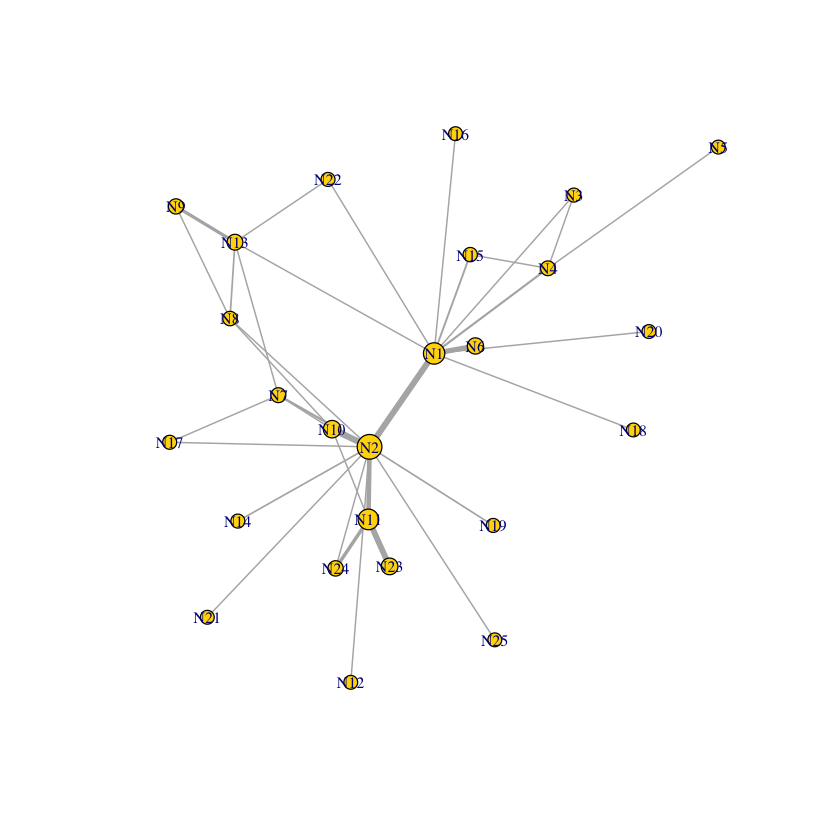

In [16]:
g <- ciel_data

# Node strength (weighted degree)
V(g)$strength <- strength(g)

# Scale node size
V(g)$size <- 5 + 4 * (V(g)$strength / max(V(g)$strength))

# Scale edge width by weight
E(g)$width <- 1 + 4 * (E(g)$weight / max(E(g)$weight))

# Light gray edges
E(g)$color <- "gray70"

# Use Fruchterman-Reingold layout
set.seed(123)
plot(g,
     layout = layout_with_fr(g),
     vertex.label.cex = 0.8,
     vertex.color = "gold")

Detect and Color Communities:

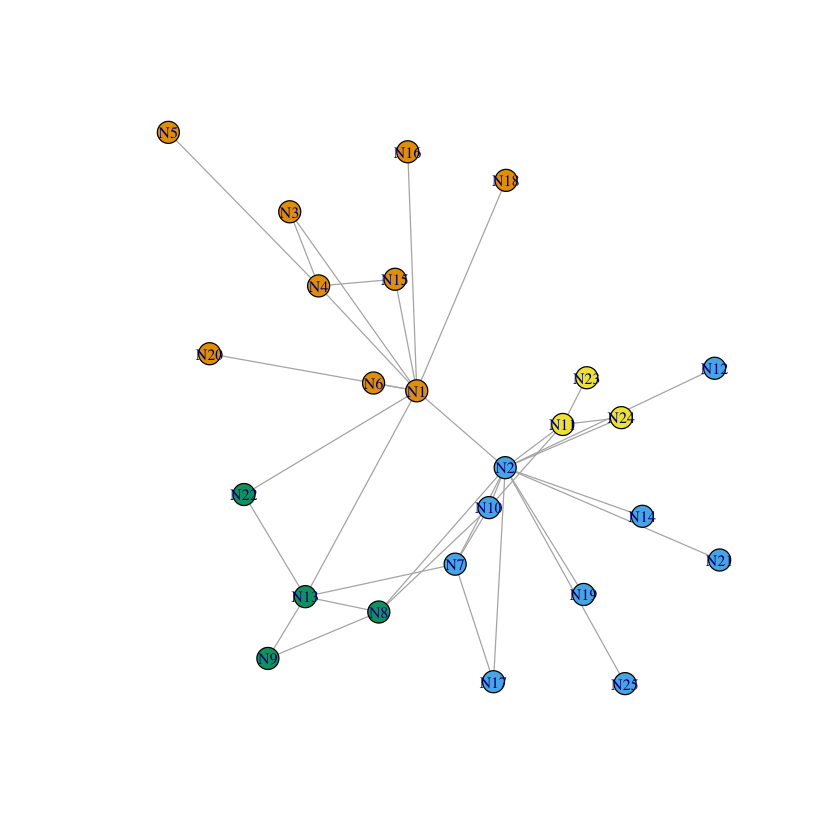

In [17]:
# Community detection (Louvain works well for weighted networks)
comm <- cluster_louvain(g, weights = E(g)$weight)

V(g)$color <- membership(comm)

plot(g,
     layout = layout_with_fr(g),
     vertex.size = 8,
     vertex.label.cex = 0.8,
     edge.width = 1)

Combine Strength + Community + Tie Strength:

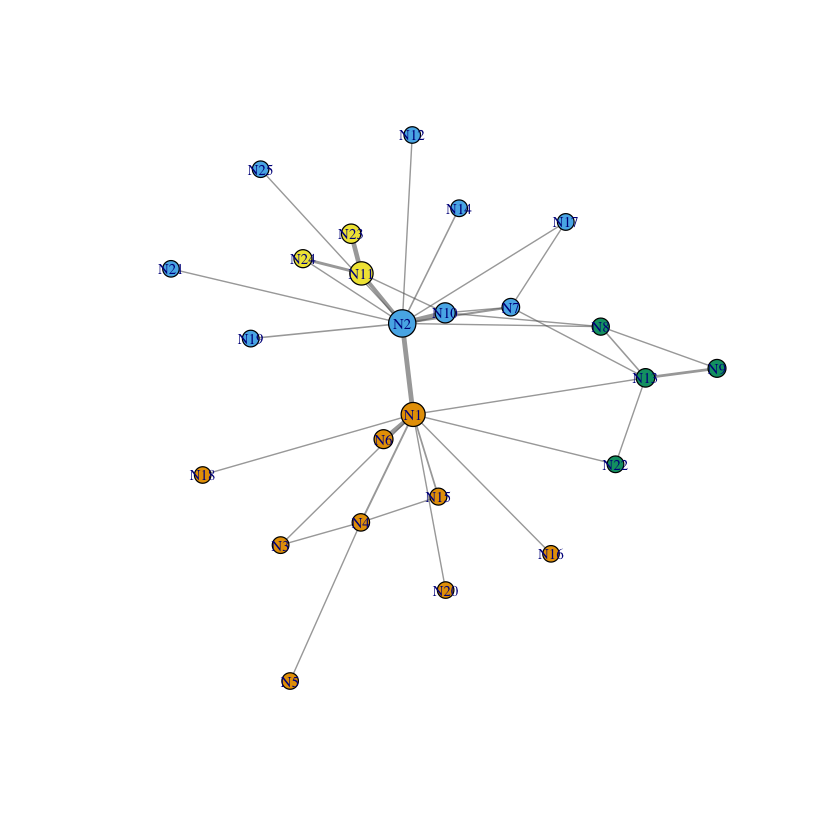

In [18]:
g <- ciel_data

# Strength for size
V(g)$size <- 6 + 4 * (strength(g) / max(strength(g)))

# Community for color
comm <- cluster_louvain(g, weights = E(g)$weight)
V(g)$color <- membership(comm)

# Edge width by weight
E(g)$width <- 1 + 3 * (E(g)$weight / max(E(g)$weight))
E(g)$color <- adjustcolor("gray40", alpha.f = 0.6)

plot(g,
     layout = layout_with_fr(g),
     vertex.label.cex = 0.75)

### Trying to Detect Communities

In [19]:
g <- ciel_data
comm <- cluster_louvain(g)  
membership <- membership(comm)

In [20]:
# Generate a color palette
library(RColorBrewer)
colors <- brewer.pal(max(membership), "Set3")  # adjust for number of communities

V(g)$color <- colors[membership]

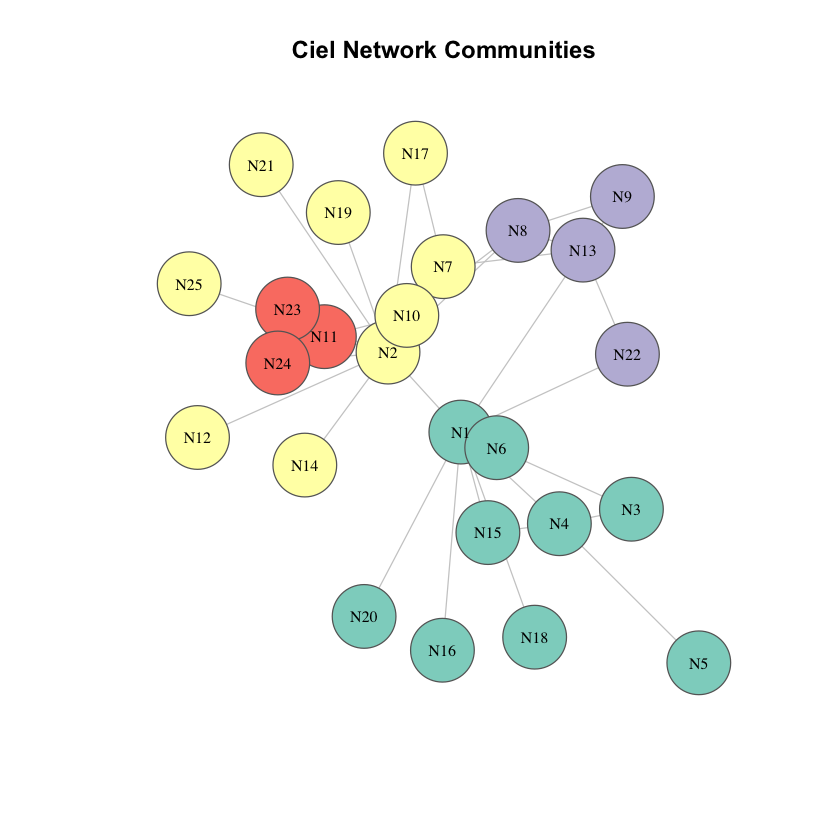

In [22]:
plot(
  g,
  vertex.size = 25,
  vertex.label.cex = 0.8,
  vertex.label.color = "black",
  vertex.frame.color = "gray40",
  edge.color = "gray80",
  layout = layout_with_fr,  # force-directed layout
  main = "Ciel Network Communities"
)

Trying out the `ggraph` library:

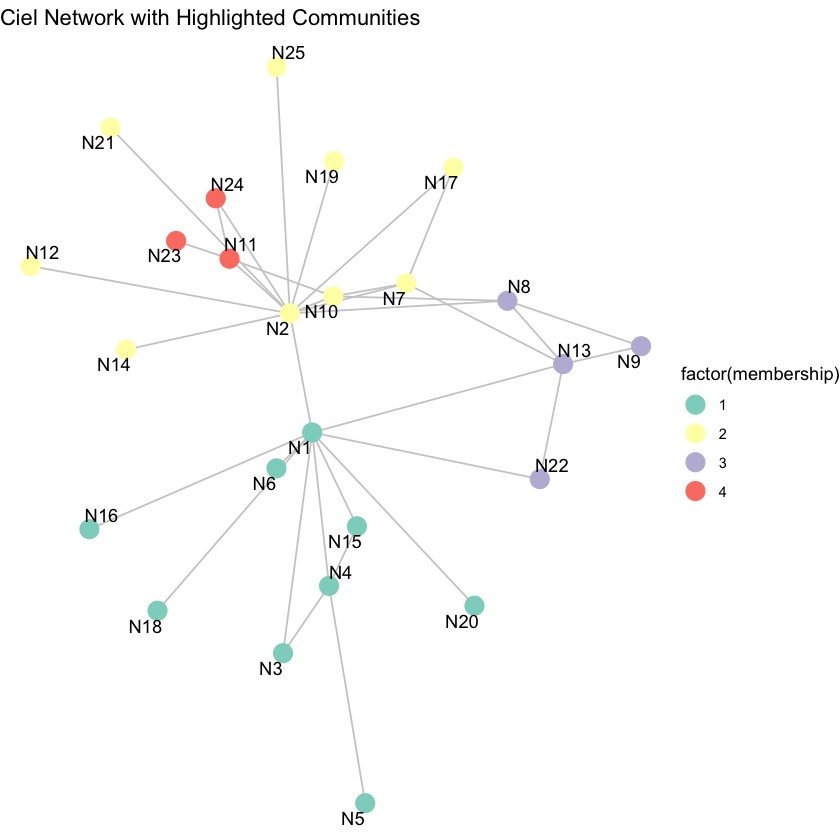

In [24]:
library(ggraph)
library(tidygraph)
g_tbl <- as_tbl_graph(g)

ggraph(g_tbl, layout = "fr") +
  geom_edge_link(color = "grey80") +
  geom_node_point(aes(color = factor(membership)), size = 5) +
  geom_node_text(aes(label = name), repel = TRUE) +
  scale_color_brewer(palette = "Set3") +
  theme_void() +
  ggtitle("Ciel Network with Highlighted Communities")

# III. Interpret the Structure

1.  Centrality Measures:

    Based on tie strength and the structure of the network, we can infer strong centrality. Nodes N1 and N2 have a high degree of centrality as well as maintain strong communication among themselves. The network can be roughly divided into 2 subsets, each connected closely to either N1 or N2. The centrality scores for centrality, betweenness etc are also very high for N1 and N2 and very low for all other nodes in the network. This indicates a concentration of communication in N1 and N2. This is very useful for identifying N1 and N2 as possible "leaders" and/or "lieutenants" in this criminal network, controlling the flow of information, influencing decisions, and possibly controlling the flow of goods and funds, too.

2.  Hierarchy Measures:

    The above interpretation continues to hold for hierarchy measures (centralization on the network level instead of on the level of individual nodes). High strength centralization (2.75) indicates unequal strength of communication in the network, while high betweenness centralization (0.74) suggests that some nodes act as important brokers, making others depend on them for communication. Closeness centralization is relatively low (0.5), which suggests that not everyone in the network is equally clsoely connected to each other. All of these measures point at low overall accessibility, indicating a stronger hierarchy where a few nodes control most communications.

3.  Community Clusters:

    Identifying and visualizing communities within this small network further reinforces the above findings. Around two-thirds of all members get classified into communities clustered around one of the central members (N1 or N2). Two smaller communities are of two types: a few members connected to both N1 and N2, and a sub-community of 3 members closely connected to each other but embedded in a larger community around N2.

4.  Overall Interpretation:

    Taken together, the centrality, hierarchy, and community analyses consistently indicate a highly concentrated and broker-driven network structure. Communication and interaction are strongly centered around N1 and N2, who dominate both in terms of tie strength and structural position. The high strength and betweenness centralization values show that interaction volume and control over communication flows are unevenly distributed, with most members depending on a small number of central actors. At the same time, the relatively low closeness centralization suggests that while many actors can reach each other indirectly, this reachability is largely mediated through the central figures rather than being evenly distributed across the network.

    The community structure further reinforces this pattern. Most actors are embedded in clusters organized around either N1 or N2, indicating two dominant spheres of influence within the broader network. Smaller subgroups either bridge between these two central actors or form tightly connected pockets within one sphere of influence. Overall, the network exhibits a broker-centered hierarchy in which a few key individuals concentrate communication, coordination, and likely decision-making power, while the remaining members occupy more peripheral and dependent positions.


# ----- RESEARCH REPORT 1 CONTENT ENDS HERE -----